In [ ]:
!pip install sastrawi
!pip install nltk
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.2 MB/s eta 0:00:00


In [ ]:
import csv
import numpy as np
import pandas as pd
# from nltk.tokenize import word_tokenize
# from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
# import string
import re

In [ ]:
!gdown --id 1e1yKmsS22gQnIoGLRrigH69L9aNf0ekG

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1e1yKmsS22gQnIoGLRrigH69L9aNf0ekG
To: /content/hasil_pre_processing.csv
100% 5.70M/5.70M [00:00<00:00, 55.3MB/s]


In [ ]:
import pandas as pd

# Path to the CSV file
csv_file = "hasil_pre_processing.csv"

# Read the CSV file into a DataFrame
docs = pd.read_csv(csv_file)

# Display the first few rows of the DataFrame
docs.head()


,Label,full_text,case_folding,cleansing,Text_Normalization,tokenization,Stemming,Stopword
0,Bahagia,@idgfbrh Bisaa lewat wa kakk?,@idgfbrh bisaa lewat wa kakk?,bisaa lewat wa kakk,bisa lewat wa kak,"['bisa', 'lewat', 'wa', 'kak']","['bisa', 'lewat', 'wa', 'kak']","['wa', 'kak']"
1,Bahagia,@sinnapreqnar 25 sih kakk. Rate berapa?,@sinnapreqnar 25 sih kakk. rate berapa?,sih kakk rate berapa,sih kak rate berapa,"['sih', 'kak', 'rate', 'berapa']","['sih', 'kak', 'rate', 'berapa']","['sih', 'kak', 'rate']"
2,Marah,@convomf tinggalin aja nder bakal bikin capek ...,@convomf tinggalin aja nder bakal bikin capek ...,tinggalin aja nder bakal bikin capek banget so...,tinggalkan saja nder bakal bikin capek banget ...,"['tinggalkan', 'saja', 'nder', 'bakal', 'bikin...","['tinggal', 'saja', 'nder', 'bakal', 'bikin', ...","['tinggal', 'nder', 'bikin', 'capek', 'banget']"
3,Sedih,kangen blu nya tirta https://t.co/uyQAEbwmuz,kangen blu nya tirta https://t.co/uyqaebwmuz,kangen blu nya tirta,kangen blu nya tirta,"['kangen', 'blu', 'nya', 'tirta']","['kangen', 'blu', 'nya', 'tirta']","['kangen', 'blu', 'nya', 'tirta']"
4,Sedih,@Bbama1409 Kak aku mau dong tapi aku gabisaa d...,@bbama1409 kak aku mau dong tapi aku gabisaa d...,kak aku mau dong tapi aku gabisaa dm kamu,kak aku mau dong tapi aku gabisaa dm kamu,"['kak', 'aku', 'mau', 'dong', 'tapi', 'aku', '...","['kak', 'aku', 'mau', 'dong', 'tapi', 'aku', '...","['kak', 'gabisaa', 'dm']"


In [ ]:
docs.tail()

,Label,full_text,case_folding,cleansing,Text_Normalization,tokenization,Stemming,Stopword
8973,Marah,dan yg emng belom tau banyak lah tentang dunia...,dan yg emng belom tau banyak lah tentang dunia...,dan yg emng belom tau banyak lah tentang dunia...,dan yang memang belum tau banyak lah tentang d...,"['dan', 'yang', 'memang', 'belum', 'tau', 'ban...","['dan', 'yang', 'memang', 'belum', 'tau', 'ban...","['tau', 'dunia', 'gue', 'sedih', 'marah', 'tau..."
8974,Marah,"aa kesel bgt anying. dia sudah di bandaraa, gi...","aa kesel bgt anying. dia sudah di bandaraa, gi...",aa kesel bgt anying dia sudah di bandaraa gift...,aa kesel banget anying dia sudah di bandaraa g...,"['aa', 'kesel', 'banget', 'anying', 'dia', 'su...","['aa', 'kesel', 'banget', 'anying', 'dia', 'su...","['aa', 'kesel', 'banget', 'anying', 'bandaraa'..."
8975,Marah,"ini segala keresahan gua udah mau ilang nihh, ...","ini segala keresahan gua udah mau ilang nihh, ...",ini segala keresahan gua udah mau ilang nihh p...,ini segala keresahan gua sudah mau hilang nih ...,"['ini', 'segala', 'keresahan', 'gua', 'sudah',...","['ini', 'segala', 'resah', 'gua', 'sudah', 'ma...","['resah', 'gua', 'hilang', 'nih', 'pokok', 'pi..."
8976,Marah,"gue pernah datang lebih awal, sebelum waktu ny...","gue pernah datang lebih awal, sebelum waktu ny...",gue pernah datang lebih awal sebelum waktu nya...,gue pernah datang lebih awal sebelum waktu nya...,"['gue', 'pernah', 'datang', 'lebih', 'awal', '...","['gue', 'pernah', 'datang', 'lebih', 'awal', '...","['gue', 'nya', 'bilang', 'kayak', 'saking', 'j..."
8977,Marah,"telat lu ngasih tau faktanya min,kalo sblm per...","telat lu ngasih tau faktanya min,kalo sblm per...",telat lu ngasih tau faktanya minkalo sblm pert...,telat lu mengasih tau faktanya minkalo sebelum...,"['telat', 'lu', 'mengasih', 'tau', 'faktanya',...","['telat', 'lu', 'asih', 'tau', 'fakta', 'minka...","['telat', 'lu', 'asih', 'tau', 'fakta', 'minka..."


In [ ]:
kelas = docs.Label.value_counts()
kelas

,count
Label,
Bahagia,2723
Marah,2492
Sedih,2001
Takut,1762


In [ ]:
# Check if there are any NaN values in the entire dataset
docs.isna().any().any()


np.False_

In [ ]:
# Identify columns with NaN values and their count
print(docs.isna().sum())


Label                 0
full_text             0
case_folding          0
cleansing             0
Text_Normalization    0
tokenization          0
Stemming              0
Stopword              0
dtype: int64


In [ ]:
# Display rows with any NaN values
docs[docs.isna().any(axis=1)]


,Label,full_text,case_folding,cleansing,Text_Normalization,tokenization,Stemming,Stopword


In [ ]:
# Drop rows with any NaN values
docs = docs.dropna()

# Verify the changes
print(f"Remaining rows after dropping NaN values: {len(docs)}")


Remaining rows after dropping NaN values: 8978


In [ ]:
# Identify columns with NaN values and their count
print(docs.isna().sum())

Label                 0
full_text             0
case_folding          0
cleansing             0
Text_Normalization    0
tokenization          0
Stemming              0
Stopword              0
dtype: int64


# Fiture Extraction

Data Split

BoW & TF IDF

In [ ]:
from sklearn.utils import resample

# Menentukan jumlah target (jumlah data per label setelah sampling)
target_count = docs['Label'].value_counts().min()

# Memisahkan dataset berdasarkan label
dfs = [docs[docs['Label'] == label] for label in docs['Label'].unique()]

# Melakukan resampling untuk menyamakan jumlah data per label
balanced_dfs = [resample(df, replace=True, n_samples=target_count, random_state=42) for df in dfs]

# Menggabungkan kembali dataset yang telah diseimbangkan
balanced_docs = pd.concat(balanced_dfs)

# Mengecek distribusi setelah sampling
print("\nDistribusi Label Setelah Sampling:")
print(balanced_docs['Label'].value_counts())


Distribusi Label Setelah Sampling:
Label
Bahagia    1762
Marah      1762
Sedih      1762
Takut      1762
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Hapus dokumen yang kosong
balanced_docs = balanced_docs[balanced_docs['tokenization'].str.strip() != '']

# Pembagian data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    balanced_docs['tokenization'],
    balanced_docs['Label'],
    test_size=0.2,
    random_state=42
)

# Menggabungkan token kembali menjadi string
X_train_str = X_train.tolist()
X_test_str = X_test.tolist()

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # Menggunakan parameter default
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_str)
X_test_tfidf = tfidf_vectorizer.transform(X_test_str)

# Bag of Words (BoW) Vectorization
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))  # Menggunakan parameter default
X_train_bow = bow_vectorizer.fit_transform(X_train_str)
X_test_bow = bow_vectorizer.transform(X_test_str)

# Menampilkan ukuran dari fitur
print("Shape of TF-IDF features:", X_train_tfidf.shape)
print("Shape of BoW features:", X_train_bow.shape)

# Mencetak jumlah data latih dan data uji untuk setiap fitur
print("Jumlah data latih (Train Data - TF-IDF):", X_train_tfidf.shape[0])
print("Jumlah data uji (Test Data - TF-IDF):", X_test_tfidf.shape[0])
print("Jumlah data latih (Train Data - BoW):", X_train_bow.shape[0])
print("Jumlah data uji (Test Data - BoW):", X_test_bow.shape[0])


Shape of TF-IDF features: (5638, 5000)
Shape of BoW features: (5638, 5000)
Jumlah data latih (Train Data - TF-IDF): 5638
Jumlah data uji (Test Data - TF-IDF): 1410
Jumlah data latih (Train Data - BoW): 5638
Jumlah data uji (Test Data - BoW): 1410


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Skalakan fitur TF-IDF
X_train_tfidf_scaled = scaler.fit_transform(X_train_tfidf.toarray())
X_test_tfidf_scaled = scaler.transform(X_test_tfidf.toarray())

# Skalakan fitur BoW
X_train_bow_scaled = scaler.fit_transform(X_train_bow.toarray())
X_test_bow_scaled = scaler.transform(X_test_bow.toarray())

# Gabungkan fitur TF-IDF dan BoW
X_train_tfidf_bow = np.hstack([X_train_tfidf_scaled, X_train_bow_scaled])
X_test_tfidf_bow = np.hstack([X_test_tfidf_scaled, X_test_bow_scaled])

# Menampilkan ukuran gabungan fitur
print("Shape of Combined TF-IDF + BoW (Train):", X_train_tfidf_bow.shape)
print("Shape of Combined TF-IDF + BoW (Test):", X_test_tfidf_bow.shape)

# Mencetak jumlah data latih dan data uji untuk kombinasi fitur
print("Jumlah data latih (Train Data - TF-IDF + BoW):", X_train_tfidf_bow.shape[0])
print("Jumlah data uji (Test Data - TF-IDF + BoW):", X_test_tfidf_bow.shape[0])


Shape of Combined TF-IDF + BoW (Train): (5638, 10000)
Shape of Combined TF-IDF + BoW (Test): (1410, 10000)
Jumlah data latih (Train Data - TF-IDF + BoW): 5638
Jumlah data uji (Test Data - TF-IDF + BoW): 1410


Distribusi label

In [ ]:
import matplotlib.pyplot as plt


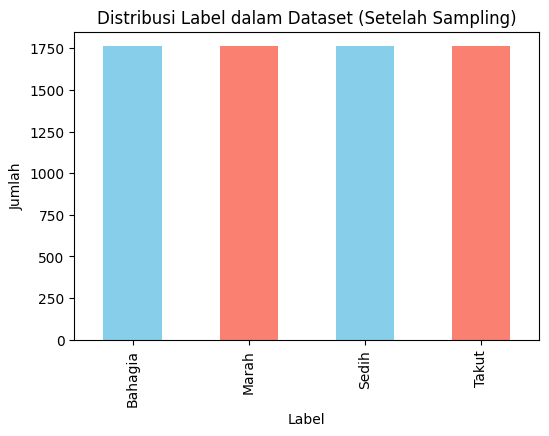

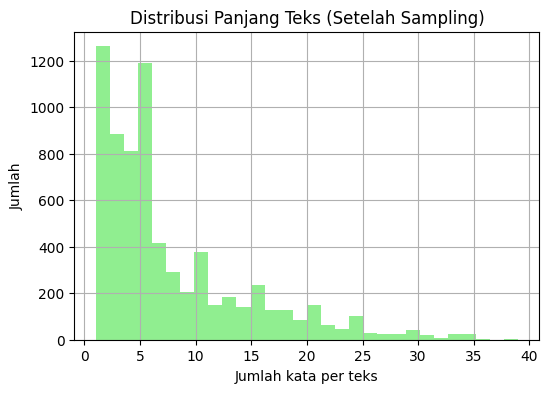

In [ ]:

# Distribusi label
plt.figure(figsize=(6, 4))
balanced_docs['Label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Distribusi Label dalam Dataset (Setelah Sampling)")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

# Distribusi panjang teks
balanced_docs['text_length'] = balanced_docs['Stopword'].apply(lambda x: len(x.split()))
plt.figure(figsize=(6, 4))
balanced_docs['text_length'].hist(bins=30, color='lightgreen')
plt.title("Distribusi Panjang Teks (Setelah Sampling)")
plt.xlabel("Jumlah kata per teks")
plt.ylabel("Jumlah")
plt.show()


# MODELLING

#Hasil Perbandingan

SVM

Classification Report for SVM (TF-IDF + BoW):
              precision    recall  f1-score   support

     Bahagia       0.84      0.76      0.80       381
       Marah       0.80      0.70      0.75       348
       Sedih       0.62      0.82      0.71       332
       Takut       0.93      0.85      0.89       349

    accuracy                           0.78      1410
   macro avg       0.80      0.78      0.79      1410
weighted avg       0.80      0.78      0.79      1410

Accuracy: 0.7830


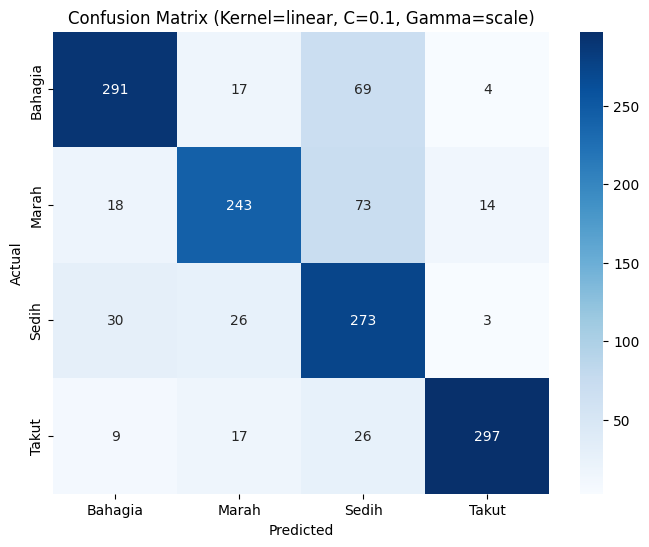

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Parameter SVM
kernel = 'linear'
C = 0.1
gamma = 'scale'

# Inisialisasi model SVM
svm_linear = SVC(C=C, kernel=kernel, gamma=gamma)

# Latih model
svm_linear.fit(X_train_tfidf_bow, y_train)

# Prediksi
y_pred_linear = svm_linear.predict(X_test_tfidf_bow)

# Evaluasi
accuracy_linear = accuracy_score(y_test, y_pred_linear)
cm_linear = confusion_matrix(y_test, y_pred_linear)
classification_report_linear = classification_report(y_test, y_pred_linear, zero_division=0)

# Simpan hasil ke dalam DataFrame untuk hasil yang lebih sederhana
linear_results = pd.DataFrame({
    "Kernel": [kernel],
    "C": [C],
    "Gamma": [gamma],
    "Accuracy": [accuracy_linear],
    "Confusion Matrix": [cm_linear.tolist()],
    "Classification Report": [classification_report_linear]
})


# Print Accuracy

print("Classification Report for SVM (TF-IDF + BoW):")
print(classification_report_linear)


print(f"Accuracy: {accuracy_linear:.4f}")

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', xticklabels=svm_linear.classes_, yticklabels=svm_linear.classes_)
plt.title(f"Confusion Matrix (Kernel={kernel}, C={C}, Gamma={gamma})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



Naive Bayes

Naive Bayes Accuracy with TF-IDF + BoW: 0.7574
Classification Report for Naive Bayes (TF-IDF + BoW):
              precision    recall  f1-score   support

     Bahagia       0.91      0.69      0.78       381
       Marah       0.70      0.76      0.73       348
       Sedih       0.66      0.73      0.70       332
       Takut       0.79      0.85      0.82       349

    accuracy                           0.76      1410
   macro avg       0.77      0.76      0.76      1410
weighted avg       0.77      0.76      0.76      1410



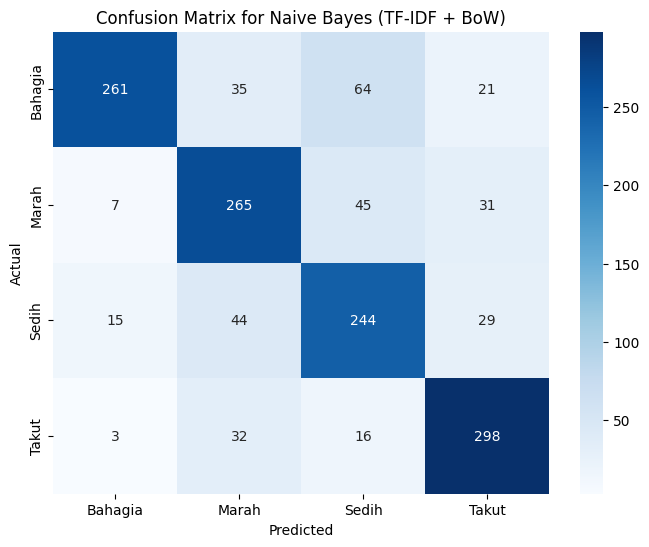

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi model Naive Bayes
nb_model = MultinomialNB()

# Fit the Naive Bayes model
nb_model.fit(X_train_tfidf_bow, y_train)

# Predict with the model
y_pred_nb_tfidf_bow = nb_model.predict(X_test_tfidf_bow)

# Calculate accuracy
accuracy_nb_tfidf_bow = accuracy_score(y_test, y_pred_nb_tfidf_bow)

# Confusion Matrix
cm_nb_tfidf_bow = confusion_matrix(y_test, y_pred_nb_tfidf_bow)

# Classification Report
classification_report_nb_tfidf_bow = classification_report(y_test, y_pred_nb_tfidf_bow, zero_division=0)

# Print Accuracy
print(f"Naive Bayes Accuracy with TF-IDF + BoW: {accuracy_nb_tfidf_bow:.4f}")

# Print Classification Report
print("Classification Report for Naive Bayes (TF-IDF + BoW):")
print(classification_report_nb_tfidf_bow)


# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb_tfidf_bow, annot=True, fmt='d', cmap='Blues', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title("Confusion Matrix for Naive Bayes (TF-IDF + BoW)")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()